PREMIÈRE APPROCHE DE RÉSOLUTION DU CAS D'ÉTUDE – DÉTERMINATION DE LA HAUTEUR DE LA DIGUE À PARTIR DES RELEVÉS DE MESURE HISTORIQUES

   Year  Q (m³/s)  H (m)
0  1849      3854    NaN
1  1850      1256    4.0
2  1851      1649    4.5
3  1852      1605    4.3
4  1853       341    1.7


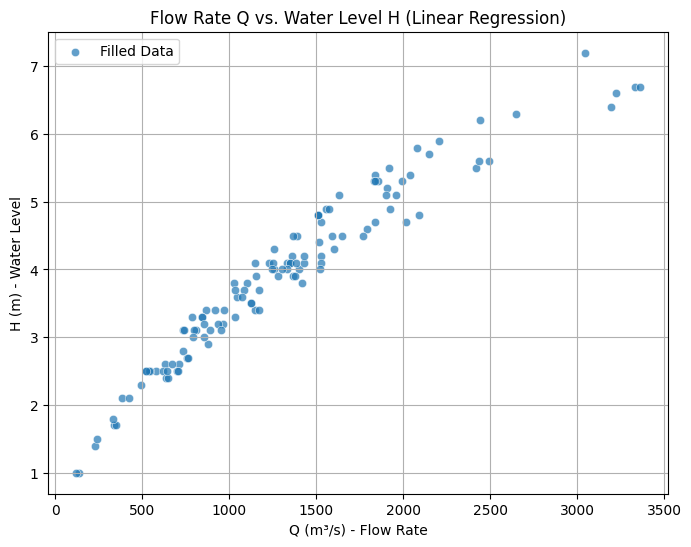

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

data = {
    "Year": list(range(1849, 1998)),
    "Q (m³/s)": [
        3854, 1256, 1649, 1605, 341, 1149, 868, 1148, 1227, 1991, 1255, 1366, 1100, 1837, 351, 1084, 1924, 843, 2647,
        1248, 2417, 1125, 903, 1462, 378, 1230, 1149, 1400, 2078, 1433, 917, 1530, 2442, 2151, 1909, 630, 2435, 1920,
        1512, 1377, 3330, 1858, 1359, 714, 1528, 1035, 1026, 1127, 1839, 771, 1730, 1889, 3320, 352, 885, 759, 731, 1711, 1906, 1543, 1307, 1275,
        2706, 582, 1260, 1331, 1283, 1348, 1048, 1348, 383, 1526, 789, 811, 1073, 965, 619, 3361, 523, 493, 424, 2017, 1958,
        3192, 1556, 1169, 1511, 1515, 2491, 881, 846, 856, 1036, 1830, 1391, 1334, 1512, 1792, 136, 891, 635,
        733, 758, 1368, 935, 1173, 547, 669, 331, 227, 2037, 3224, 1525, 766, 1575, 1695, 1235, 1454, 2595, 706, 1837, 1629,
        1421, 2204, 956, 971, 1383, 541, 703, 2090, 800, 651, 1153, 704, 1771, 1433, 238, 122, 1306, 733, 793, 856,
        1903, 1594, 740, 3044, 1128, 522, 642
    ],
    "H (m)": [
        np.nan, 4.0, 4.5, 4.3, 1.7, 3.4, 3.4, 4.1, 4.1, 5.3, 4.1, 3.9, 3.8, 5.4, 1.7, 3.7, 4.9, 3.3, 6.3, 4.0, 5.5, np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,
        4.0, 5.8, 4.1, 3.4, 4.7, 6.2, 5.7, 5.2, 2.6, 5.6, 5.5, 4.8, 3.9, 6.7, 5.3, 4.2, 2.6, 4.2, 3.3, 3.8, 3.5, 4.7, np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,
        np.nan, 2.5, 4.3, 4.1, 3.9, 4.1, 3.6, 4.1, 2.1, 4.1, 3.3, 3.1, 3.6, 3.2, 2.5, 6.7, 2.5, 2.3, 2.1, 4.7, 5.1, 6.4, 4.9, 3.4, 4.8, 4.4, 5.6, 2.9, 3.3, 3.2, 3.7, 5.3,
        4.5, 4.0, 4.8, 4.6, 1.0, 3.1, 2.4, 2.8, 2.7, 4.5, 3.2, 3.7, 2.5, 2.6, 1.8, 1.4, 5.4, 6.6, 4.0, 2.7, 4.9, np.nan,np.nan,np.nan,np.nan,np.nan,
        5.3, 5.1, 3.8, 5.9, 3.1, 3.4, 4.1, 2.5, 2.5, 4.8, 3.1, 2.4, 3.9, 2.5, 4.5, 4.2, 1.5, 1.0, 4.0, 3.1, 3.0, 3.0, 5.1, 4.5, 3.1, 7.2, 3.5, 2.5, 2.5
    ]

}

# Create DataFrame
df = pd.DataFrame(data)
print(df.head())

# Visualize regression results
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df["Q (m³/s)"], y=df["H (m)"], alpha=0.7, label="Filled Data")
plt.xlabel("Q (m³/s) - Flow Rate")
plt.ylabel("H (m) - Water Level")
plt.title("Flow Rate Q vs. Water Level H (Linear Regression)")
plt.grid(True)

plt.legend()
plt.show()

   Year  Q (m³/s)     H (m)
0  1849      3854  8.493051
1  1850      1256  4.000000
2  1851      1649  4.500000
3  1852      1605  4.300000
4  1853       341  1.700000


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


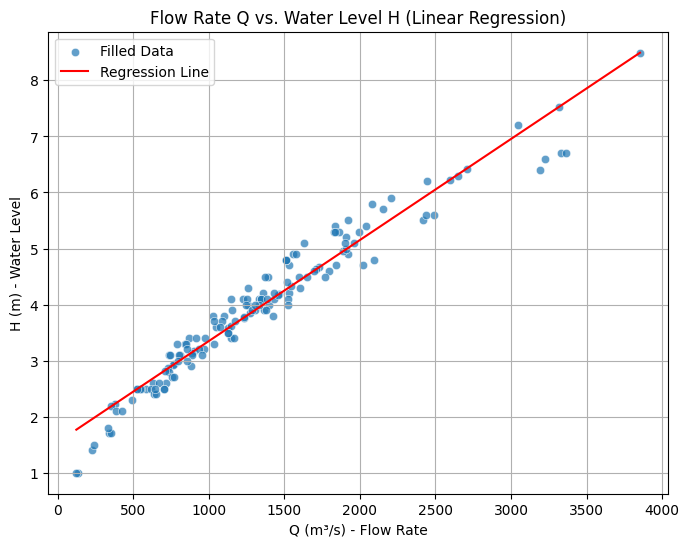

In [ ]:
# Select non-null data for regression modeling
df_non_null = df.dropna(subset=["H (m)"])
X_train = df_non_null[["Q (m³/s)"]]  # Independent variable
y_train = df_non_null["H (m)"]  # Dependent variable

# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict missing values
df_missing = df[df["H (m)"].isna()].copy()
df_missing["H (m)"] = model.predict(df_missing[["Q (m³/s)"]])

# Fill missing values in the original dataset
df_filled = df.copy()
df_filled.loc[df_filled["H (m)"].isna(), "H (m)"] = df_missing["H (m)"]

# Display the filled dataset
print(df_filled.head())

# Visualize regression results
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_filled["Q (m³/s)"], y=df_filled["H (m)"], alpha=0.7, label="Filled Data")
plt.xlabel("Q (m³/s) - Flow Rate")
plt.ylabel("H (m) - Water Level")
plt.title("Flow Rate Q vs. Water Level H (Linear Regression)")
plt.grid(True)

# Plot regression line
Q_range = np.linspace(df_filled["Q (m³/s)"].min(), df_filled["Q (m³/s)"].max(), 100).reshape(-1, 1)
H_pred = model.predict(Q_range)
plt.plot(Q_range, H_pred, color="red", label="Regression Line")

plt.legend()
plt.show()

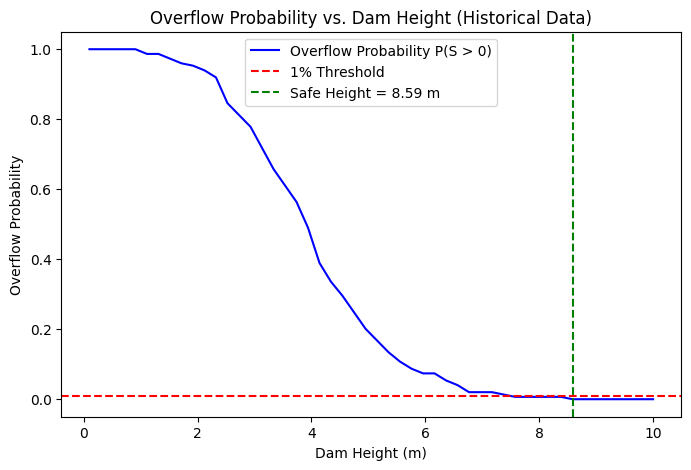

Minimum dam height meeting safety standard based on historical data: 8.59 m


In [ ]:
# Define the range of dam heights
hd_values = np.linspace(0.1, 10, 50)  # From 0.1m to 10m, divided into 50 values

# Calculate overflow probability
P_overflow = []

for hd in hd_values:
    S_samples = df_filled["H (m)"] - hd  # Calculate overflow height
    P_over = np.mean(S_samples > 0)  # Compute overflow probability
    P_overflow.append(P_over)

# Find the minimum h_d that satisfies P(S > 0) < 0.01
safe_hd = hd_values[np.where(np.array(P_overflow) < 0.001)[0][0]]

# Plot the overflow probability curve
plt.figure(figsize=(8, 5))
plt.plot(hd_values, P_overflow, label="Overflow Probability P(S > 0)", color='blue')
plt.axhline(y=0.01, color='r', linestyle='--', label="1% Threshold")
plt.axvline(x=safe_hd, color='g', linestyle='--', label=f"Safe Height = {safe_hd:.2f} m")
plt.xlabel("Dam Height (m)")
plt.ylabel("Overflow Probability")
plt.legend()
plt.title("Overflow Probability vs. Dam Height (Historical Data)")
plt.show()

print(f"Minimum dam height meeting safety standard based on historical data: {safe_hd:.2f} m")


DEUXIÈME APPROCHE DE RÉSOLUTION DU CAS D'ÉTUDE – DÉTERMINATION DE LA HAUTEUR
DE LA DIGUE À PARTIR DU MODÈLE HYDRAULIQUE

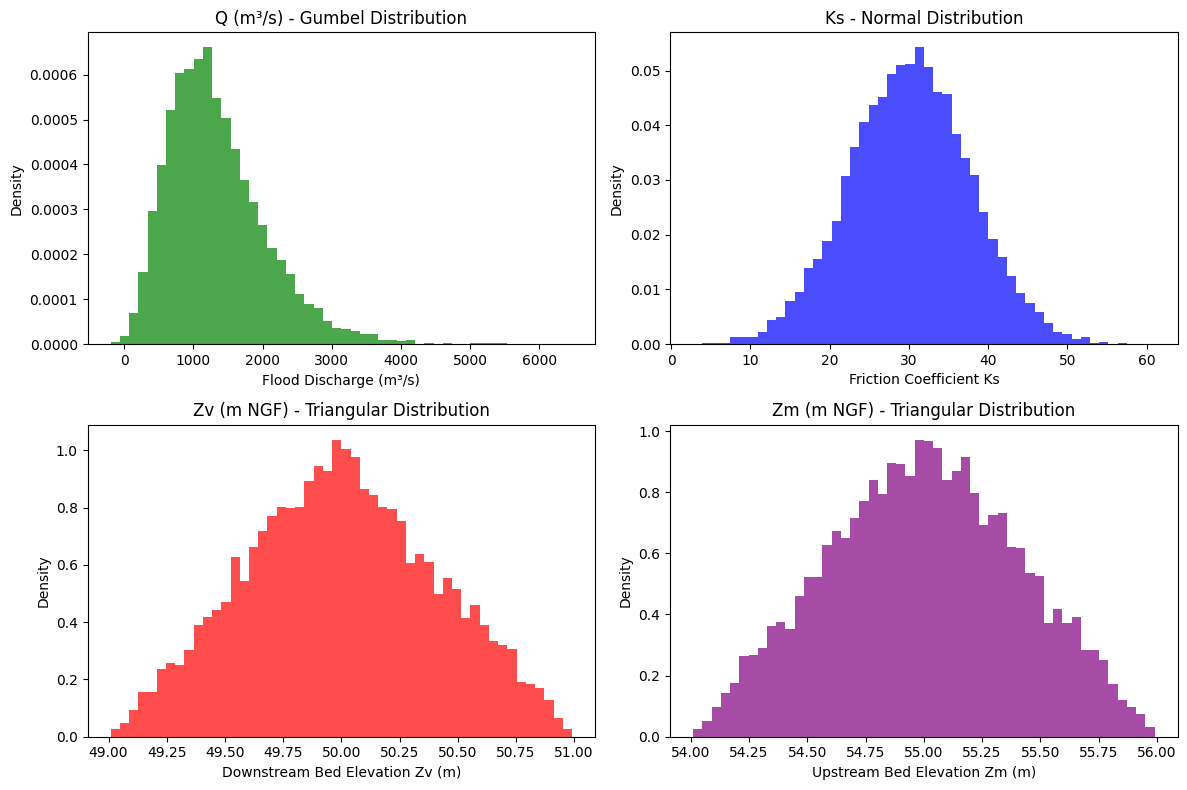

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Define distribution parameters
Q_mode, Q_scale = 1013, 558  # Gumbel distribution parameters
Ks_mean, Ks_std = 30, 7.5  # Normal distribution parameters
Zv_mean, Zv_half_range = 50, 1  # Triangular distribution parameters
Zm_mean, Zm_half_range = 55, 1  # Triangular distribution parameters

# Fixed parameters
L = 5000  # River length (m)
B = 300  # River width (m)
Zb = 55.5  # Riverbank elevation (m)

# Generate random samples
Q_samples = stats.gumbel_r.rvs(loc=Q_mode, scale=Q_scale, size=10000)
Ks_samples = stats.norm.rvs(loc=Ks_mean, scale=Ks_std, size=10000)
Zv_samples = stats.triang.rvs(c=0.5, loc=Zv_mean-Zv_half_range, scale=2*Zv_half_range, size=10000)
Zm_samples = stats.triang.rvs(c=0.5, loc=Zm_mean-Zm_half_range, scale=2*Zm_half_range, size=10000)

# Plot the probability distributions of 4 variables
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Flood discharge Q
axes[0, 0].hist(Q_samples, bins=50, density=True, color='green', alpha=0.7)
axes[0, 0].set_title("Q (m³/s) - Gumbel Distribution")
axes[0, 0].set_xlabel("Flood Discharge (m³/s)")
axes[0, 0].set_ylabel("Density")

# Friction coefficient Ks
axes[0, 1].hist(Ks_samples, bins=50, density=True, color='blue', alpha=0.7)
axes[0, 1].set_title("Ks - Normal Distribution")
axes[0, 1].set_xlabel("Friction Coefficient Ks")
axes[0, 1].set_ylabel("Density")

# Downstream bed elevation Zv
axes[1, 0].hist(Zv_samples, bins=50, density=True, color='red', alpha=0.7)
axes[1, 0].set_title("Zv (m NGF) - Triangular Distribution")
axes[1, 0].set_xlabel("Downstream Bed Elevation Zv (m)")
axes[1, 0].set_ylabel("Density")

# Upstream bed elevation Zm
axes[1, 1].hist(Zm_samples, bins=50, density=True, color='purple', alpha=0.7)
axes[1, 1].set_title("Zm (m NGF) - Triangular Distribution")
axes[1, 1].set_xlabel("Upstream Bed Elevation Zm (m)")
axes[1, 1].set_ylabel("Density")

plt.tight_layout()
plt.show()

<ipython-input-6-0dcddd60d9a2>:3: RuntimeWarning: invalid value encountered in power
  H_samples = (Q_samples / (Ks_samples * np.sqrt((Zm_samples - Zv_samples) / L) * B))**(3/5)


10000


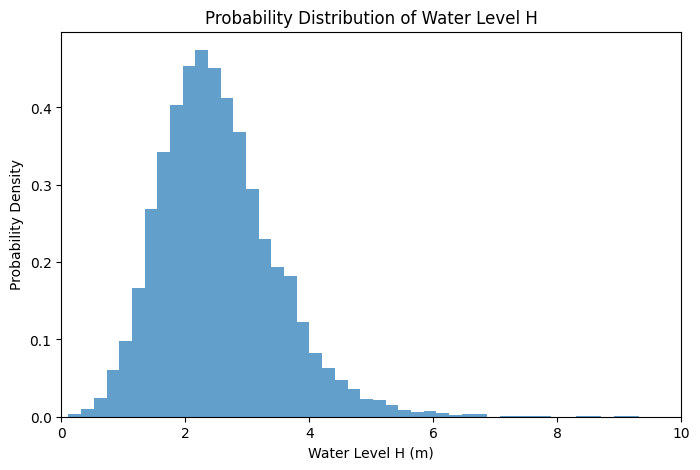

In [ ]:
# Compute water level H
H_all = []
H_samples = (Q_samples / (Ks_samples * np.sqrt((Zm_samples - Zv_samples) / L) * B))**(3/5)
H_all.extend(H_samples)
print(len(H_samples))

# Plot H distribution
plt.figure(figsize=(8, 5))
plt.hist(H_all, bins=50, density=True, alpha=0.7)
plt.xlabel("Water Level H (m)")
plt.ylabel("Probability Density")
plt.title("Probability Distribution of Water Level H")
plt.xlim(0, 10)  # Set x-axis limits from 0 to 10 meters
plt.show()

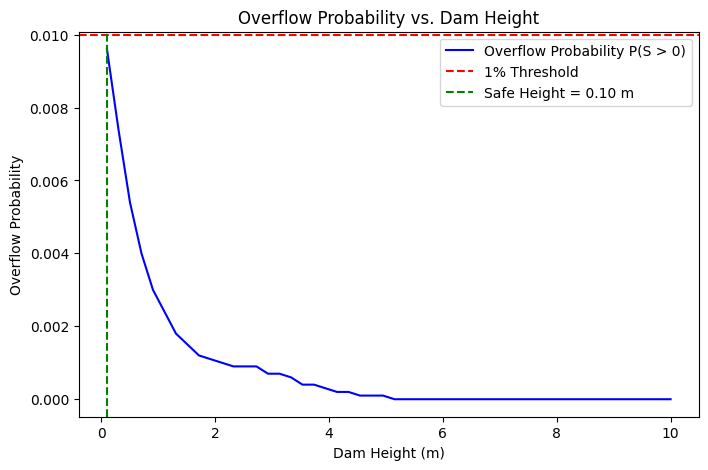

Minimum dam height meeting safety standard: 0.10 m


In [ ]:
# Define dam height range
hd_values = np.linspace(0.1, 10, 50)  # 50 values from 0.1m to 10m

# Compute overflow probability
P_overflow = []  # Store overflow probabilities

for hd in hd_values:
    # Compute overflow height S
    S_samples = Zv_samples + H_samples - hd - Zb
    #S_samples = H_samples - hd
    #print(len(S_samples))

    # Compute overflow probability P(S > 0)
    P_over = np.mean(S_samples > 0)
    #P_over = np.sum(S_samples > 0) / len(S_samples)

    P_overflow.append(P_over)

# Find the minimum hd that satisfies P(S > 0) < 1%
#safe_hd = np.interp(0.01, P_overflow[::-1], hd_values[::-1])  # 反向插值，确保找到最早满足条件的 h_d
safe_hd = hd_values[np.where(np.array(P_overflow) < 0.01)[0][0]]

# Plot overflow probability curve
plt.figure(figsize=(8, 5))
plt.plot(hd_values, P_overflow, label="Overflow Probability P(S > 0)", color='blue')
plt.axhline(y=0.01, color='r', linestyle='--', label="1% Threshold")
plt.axvline(x=safe_hd, color='g', linestyle='--', label=f"Safe Height = {safe_hd:.2f} m")
plt.xlabel("Dam Height (m)")
plt.ylabel("Overflow Probability")
plt.legend()
plt.title("Overflow Probability vs. Dam Height")
plt.show()


print(f"Minimum dam height meeting safety standard: {safe_hd:.2f} m")


TROISIÈME APPROCHE DE RÉSOLUTION DU CAS D'ÉTUDE – DÉTERMINATION DE LA HAUTEUR
DE LA DIGUE À PARTIR DU MODÈLE ÉCONOMIQUE

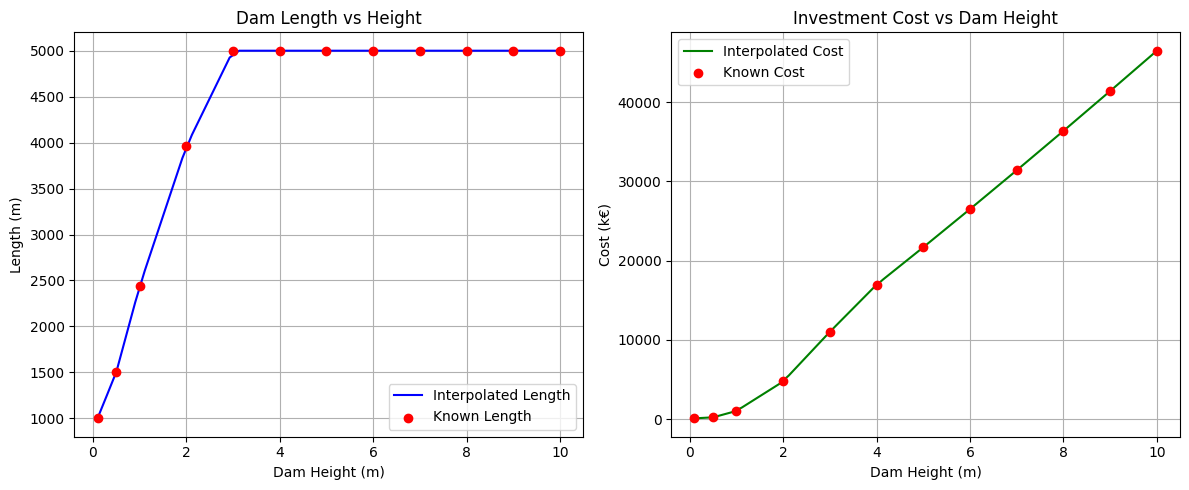

In [ ]:
# Define known dam heights, lengths, and costs
hd_known = np.array([0.1, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
length_known = np.array([1000, 1500, 2437, 3959, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000])
cost_known = np.array([100, 225, 1034, 4750, 11023, 16971, 21692, 26509, 31408, 36377, 41409, 46498])

# Define the range of dam heights
hd_values = np.linspace(0.1, 10, 50)  # Generate 50 values between 0.1 and 10

# Use interpolation to compute dam length and cost for any height
dam_length = np.interp(hd_values, hd_known, length_known)
investment_cost = np.interp(hd_values, hd_known, cost_known)

plt.figure(figsize=(12, 5))

# Plot the relationship between length and dam height
plt.subplot(1, 2, 1)
plt.plot(hd_values, dam_length, label="Interpolated Length", color="blue")
plt.scatter(hd_known, length_known, color='red', label="Known Length", zorder=5)
plt.title("Dam Length vs Height")
plt.xlabel("Dam Height (m)")
plt.ylabel("Length (m)")
plt.legend()
plt.grid(True)

# Plot the relationship between cost and dam height
plt.subplot(1, 2, 2)
plt.plot(hd_values, investment_cost, label="Interpolated Cost", color="green")
plt.scatter(hd_known, cost_known, color='red', label="Known Cost", zorder=5)
plt.title("Investment Cost vs Dam Height")
plt.xlabel("Dam Height (m)")
plt.ylabel("Cost (k€)")
plt.legend()
plt.grid(True)

# Display the two subplots
plt.tight_layout()
plt.show()


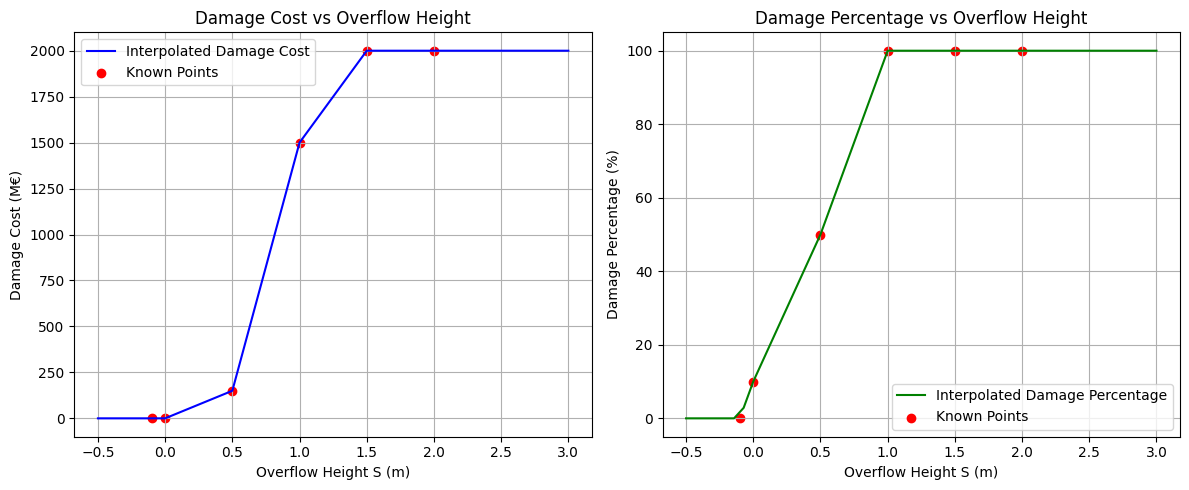

In [ ]:
# Define known data points
S_known = np.array([-0.1, 0, 0.5, 1, 1.5, 2])
Cs_known = np.array([0, 0, 150, 1500, 2000, 2000])  # Damage cost (M€)
Cg_known = np.array([0, 10, 50, 100, 100, 100])     # Damage percentage

# Define S values for interpolation
S_values = np.linspace(-0.5, 3, 50)

# Perform linear interpolation using np.interp()
Cs_values = np.interp(S_values, S_known, Cs_known)
Cg_values = np.interp(S_values, S_known, Cg_known)

# Plot the interpolation curves
plt.figure(figsize=(12, 5))

# Damage cost curve
plt.subplot(1, 2, 1)
plt.plot(S_values, Cs_values, label="Interpolated Damage Cost", color='blue')
plt.scatter(S_known, Cs_known, color='red', label="Known Points")
plt.title("Damage Cost vs Overflow Height")
plt.xlabel("Overflow Height S (m)")
plt.ylabel("Damage Cost (M€)")
plt.legend()
plt.grid(True)

# Damage percentage curve
plt.subplot(1, 2, 2)
plt.plot(S_values, Cg_values, label="Interpolated Damage Percentage", color='green')
plt.scatter(S_known, Cg_known, color='red', label="Known Points")
plt.title("Damage Percentage vs Overflow Height")
plt.xlabel("Overflow Height S (m)")
plt.ylabel("Damage Percentage (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
H_all = []
S_all = []

for i, hd in enumerate(hd_values):
    # Current dam length
    L = dam_length[i]

    # Recalculate H (water level)
    H_samples = (Q_samples / (Ks_samples * np.sqrt((Zm_samples - Zv_samples) / L) * B)) ** (3/5)
    H_all.extend(H_samples)

    # Calculate overflow height S
    S_samples = Zv_samples + H_samples - hd - Zb
    #S_samples = H_samples - hd

    S_all.extend(S_samples)

plt.figure(figsize=(13, 5))  # Create a figure with 1 row and 2 columns

# === Plot: Distribution of water level H ===
plt.subplot(1, 2, 1)  # First column
plt.hist(H_all, bins=50, density=True, alpha=0.7, label="Water Level H")
plt.xlabel("Water Level H (m)")
plt.ylabel("Probability Density")
plt.title("Probability Distribution of Water Level H")
plt.xlim(0, 10)  # Set x-axis limit between 0 and 10 meters
plt.legend()
plt.grid(True)

# === Plot: Distribution of overflow height S ===
plt.subplot(1, 2, 2)  # Second column
plt.hist(S_all, bins=50, density=True, alpha=0.7, color='red', label="Overflow Height S")
plt.xlabel("Overflow Height S (m)")
plt.ylabel("Probability Density")
plt.title("Probability Distribution of Overflow Height S")
plt.axvline(x=0, color='black', linestyle='--', label="No Overflow Threshold")  # Mark overflow threshold
plt.xlim(-2, 5)  # Set x-axis limit between -2 and 5 meters
plt.legend()
plt.grid(True)

# === Display in the same window ===
plt.tight_layout()  # Adjust spacing to prevent overlap
plt.show()


<ipython-input-14-6ee3e378613f>:9: RuntimeWarning: invalid value encountered in power
  H_samples = (Q_samples / (Ks_samples * np.sqrt((Zm_samples - Zv_samples) / L) * B)) ** (3/5)


KeyboardInterrupt: 

In [ ]:
H_all = []
S_mean = []  # Store the mean overflow height for each dam height

for i, hd in enumerate(hd_values):
    # Current dam length
    L = dam_length[i]

    # Recalculate H (water level)
    H_samples = (Q_samples / (Ks_samples * np.sqrt((Zm_samples - Zv_samples) / L) * B)) ** (3/5)
    H_all.extend(H_samples)

    # Calculate overflow height S
    S_samples = Zv_samples + H_samples - hd - Zb
    #S_samples = H_samples - hd

    # Store only the mean overflow height
    # S_mean.append(np.mean(S_samples))
    S_mean.append(np.nanmean(S_samples))

print(len(S_mean))
print(len(H_all))
# print(np.mean(S_samples))

# === Plot: Distribution of water level H ===
plt.figure(figsize=(13, 5))  # Create a figure with 1 row and 2 columns
plt.subplot(1, 2, 1)  # First column
plt.hist(H_all, bins=50, density=True, alpha=0.7, label="Water Level H")
plt.xlabel("Water Level H (m)")
plt.ylabel("Probability Density")
plt.title("Probability Distribution of Water Level H")
plt.xlim(0, 10)  # Set x-axis limit between 0 and 10 meters
plt.legend()
plt.grid(True)

# === Plot: Mean overflow height vs dam height ===
plt.subplot(1, 2, 2)  # Second column
plt.plot(hd_values, S_mean, color='red', marker='o', label="Mean Overflow Height")  # Plot the mean curve
plt.axhline(y=0, color='black', linestyle='--', label="No Overflow Threshold")  # Mark overflow threshold
plt.xlabel("Dam Height $h_d$ (m)")
plt.ylabel("Mean Overflow Height $S$ (m)")
plt.title("Mean Overflow Height vs Dam Height")
plt.xlim(min(hd_values), max(hd_values))
plt.grid(True)
plt.legend()

# === Display in the same window ===
plt.tight_layout()  # Adjust spacing to prevent overlap
plt.show()


NameError: name 'hd_values' is not defined

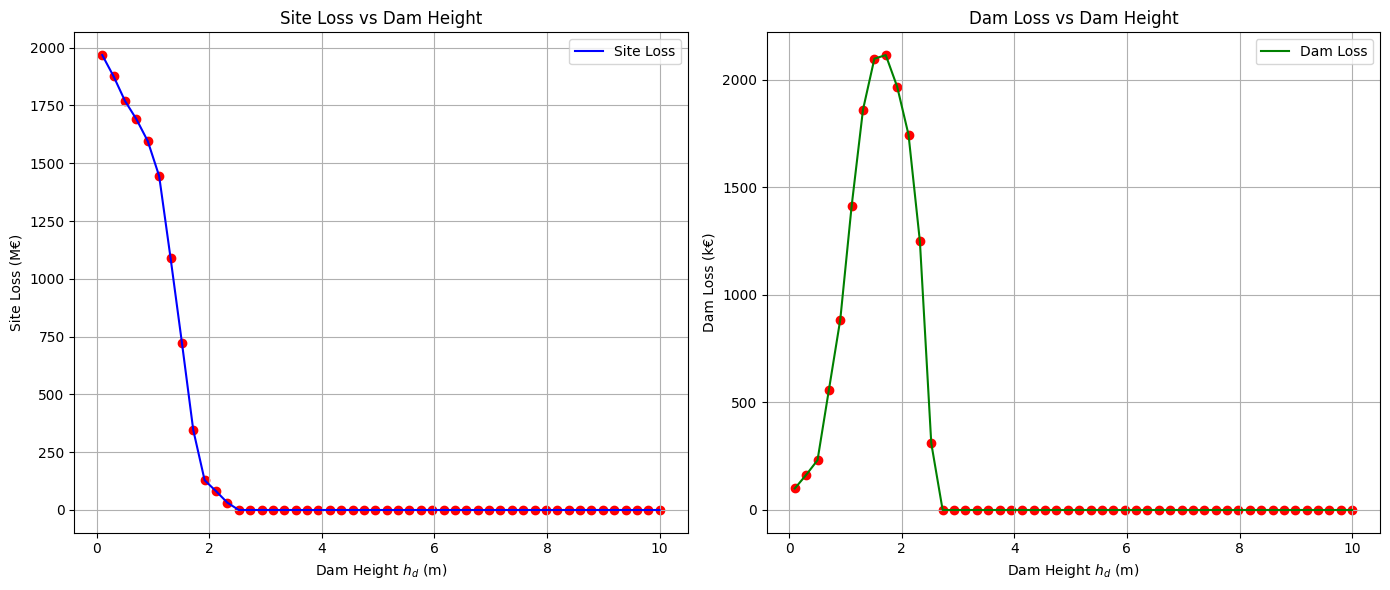

In [ ]:
# Compute site loss and dam loss
site_loss = np.interp(S_mean, S_known, Cs_known)  # Site loss (M€)
dam_loss = np.interp(S_mean, S_known, Cg_known) * investment_cost / 100  # Dam loss (in k€)

# === Plot: Relationship between dam height and site loss ===
plt.figure(figsize=(14, 6))

# Site loss vs dam height
plt.subplot(1, 2, 1)
plt.plot(hd_values, site_loss, color='blue', label="Site Loss")
plt.scatter(hd_values, site_loss, color='red')
plt.title("Site Loss vs Dam Height")
plt.xlabel("Dam Height $h_d$ (m)")
plt.ylabel("Site Loss (M€)")
plt.grid(True)
plt.legend()

# Dam loss vs dam height
plt.subplot(1, 2, 2)
plt.plot(hd_values, dam_loss, color='green', label="Dam Loss")
plt.scatter(hd_values, dam_loss, color='red')
plt.title("Dam Loss vs Dam Height")
plt.xlabel("Dam Height $h_d$ (m)")
plt.ylabel("Dam Loss (k€)")
plt.grid(True)
plt.legend()

# Display two plots in the same row
plt.tight_layout()
plt.show()


<ipython-input-13-d6c53942085d>:27: RuntimeWarning: invalid value encountered in power
  H_samples = (Q_samples[year, :] / (Ks_samples * np.sqrt((Zm_samples - Zv_samples) / L) * B)) ** (3/5)


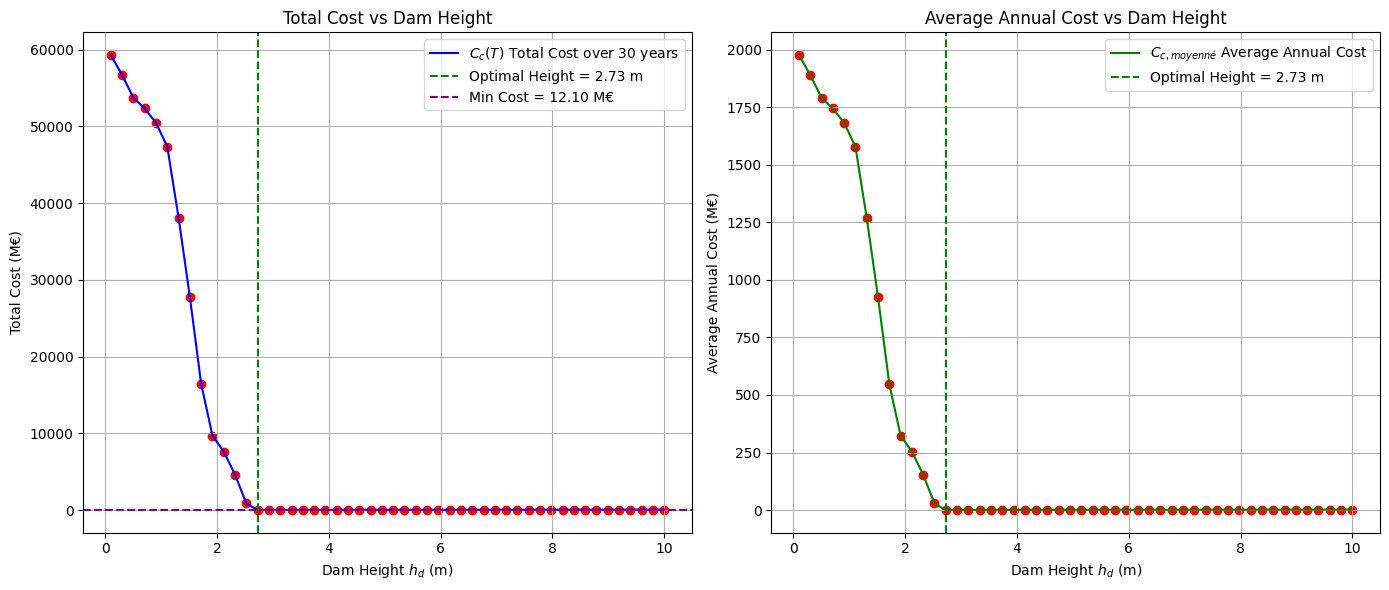

✅ Optimal dam height: 2.73 m
✅ Minimum total cost: 12.10 M€


In [ ]:
T = 30
n_samples = 10000

# === 1. Convert investment cost from k€ to M€ ===
C_i = investment_cost * 0.001                                # Convert k€ to M€

# === 2. Compute annual maintenance cost ===
C_m = 0.01 * C_i                                             # Annual maintenance cost C_m(h_d)

# === 3. Compute total investment and maintenance cost (30 years) ===
C_t = C_i + T * C_m

# === 4. Compute total overflow loss cost ===
# Generate Q_samples for a 30-year period (10,000 samples per year)
Q_samples = np.random.gumbel(Q_mode, Q_scale, (T, n_samples))

# Store annual mean values of H and S (for each dam height)
H_mean = np.zeros((T, len(hd_values)))
S_mean = np.zeros((T, len(hd_values)))

for year in range(T):
    for i, hd in enumerate(hd_values):
        # Current dam length
        L = dam_length[i]

        # Generate H (water level) for each year => 10,000 samples
        H_samples = (Q_samples[year, :] / (Ks_samples * np.sqrt((Zm_samples - Zv_samples) / L) * B)) ** (3/5)

        # Generate S (overflow height) for each year => 10,000 samples
        S_samples = H_samples - hd

        # Store mean values
        H_mean[year, i] = np.nanmean(H_samples)
        S_mean[year, i] = np.nanmean(S_samples)

# Interpolate to compute site loss and dam loss
Cs = np.interp(S_mean, S_known, Cs_known)
Cg = np.interp(S_mean, S_known, Cg_known) * investment_cost * 0.001

# Total annual loss
Cd = Cs + Cg

# Total loss over 30 years
Cd_total = np.sum(Cd, axis=0)

# === 6. Compute total cost over 30 years ===
C_c = C_t + Cd_total

# === 7. Compute average annual cost ===
C_c_moyenne = C_c / T

# === 8. Find the optimal dam height (minimizing total cost) ===
optimal_hd = hd_values[np.argmin(C_c)]                       # Find the dam height with minimum total cost
min_cost = np.min(C_c)                                        # Minimum total cost

# === 9. Plot the results ===
plt.figure(figsize=(14, 6))

# Total cost vs dam height
plt.subplot(1, 2, 1)
plt.plot(hd_values, C_c, color='blue', label=r"$C_c(T)$ Total Cost over 30 years")
plt.scatter(hd_values, C_c, color='red')
# Mark the optimal point
plt.axvline(x=optimal_hd, color='green', linestyle='--', label=f"Optimal Height = {optimal_hd:.2f} m")
plt.axhline(y=min_cost, color='purple', linestyle='--', label=f"Min Cost = {min_cost:.2f} M€")
plt.title("Total Cost vs Dam Height")
plt.xlabel("Dam Height $h_d$ (m)")
plt.ylabel("Total Cost (M€)")       # Unit in M€
plt.grid(True)
plt.legend()

# Average annual cost vs dam height
plt.subplot(1, 2, 2)
plt.plot(hd_values, C_c_moyenne, color='green', label=r"$C_{c, moyenné}$ Average Annual Cost")
plt.scatter(hd_values, C_c_moyenne, color='red')
# Mark the optimal point
plt.axvline(x=optimal_hd, color='green', linestyle='--', label=f"Optimal Height = {optimal_hd:.2f} m")
plt.title("Average Annual Cost vs Dam Height")
plt.xlabel("Dam Height $h_d$ (m)")
plt.ylabel("Average Annual Cost (M€)")   # Unit in M€
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# === 10. Output results ===
print(f"✅ Optimal dam height: {optimal_hd:.2f} m")
print(f"✅ Minimum total cost: {min_cost:.2f} M€")
